### Dependencies

In [ ]:
%pip install networkx
%pip install numpy
%pip install scikit-learn
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import networkx as nx
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import LocalOutlierFactor
import copy

In [12]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import warnings
warnings.filterwarnings('default')

### Exercise 1

In [3]:
def ex1_1(num_maximum_edges=None):
    astro_ph_file = open('ca-AstroPh.txt', 'r')

    edge_weights = dict()
    for idx, line in enumerate(astro_ph_file):
        node_0, node_1 = line.strip().split()
        node_0 = int(node_0)
        node_1 = int(node_1)

        if node_0 > node_1:
            aux = node_0
            node_0 = node_1
            node_1 = aux

        edge = (node_0, node_1)
        if edge not in edge_weights:
            edge_weights[edge] = 0
        edge_weights[edge] += 1

        if num_maximum_edges is not None:
            if idx == num_maximum_edges - 1:
                break

    astro_ph_file.close()

    G = nx.Graph()
    for edge, weight in edge_weights.items():
        node_0, node_1 = edge
        G.add_edge(node_0, node_1, weight=weight)

    print(f'Number of Nodes: {G.number_of_nodes()}')
    print(f'Number of Edges: {G.number_of_edges()}')

    return G


graph_ex1_1 = ex1_1(num_maximum_edges=None)

Number of Nodes: 18772
Number of Edges: 198110


In [4]:
def ex1_2(graph):
    
    for node in graph.nodes():
        neighbors = list(graph.neighbors(node))
        egonet = graph.subgraph(neighbors)

        egonet_num_neighbors = len(neighbors)
        egonet_num_edges = egonet.number_of_edges()
        egonet_total_weight = sum([data['weight'] for _, _, data in egonet.edges(data=True)])

        if egonet_num_neighbors == 0:
            principal_eigen_value = 0.0
        else:
            adjacency_matrix = nx.adjacency_matrix(egonet, weight='weight').todense()
            eigen_values = np.linalg.eigvals(adjacency_matrix)
            principal_eigen_value = eigen_values[np.argmax(np.real(eigen_values))].real

        graph.nodes[node]['egonet_num_neighbors'] = egonet_num_neighbors
        graph.nodes[node]['egonet_num_edges'] = egonet_num_edges
        graph.nodes[node]['egonet_total_weight'] = egonet_total_weight
        graph.nodes[node]['egonet_principal_eigen_value'] = principal_eigen_value

    return graph


graph_ex1_2 = ex1_2(graph_ex1_1)

In [5]:
def ex1_3(graph):

    nodes = np.array(list(graph.nodes()))
    egonet_num_neighbors = np.array([graph.nodes[node]['egonet_num_neighbors'] for node in graph.nodes()])
    egonet_num_edges = np.array([graph.nodes[node]['egonet_num_edges'] for node in graph.nodes()])

    filter_mask = ((0 < egonet_num_neighbors) & (0 < egonet_num_edges))
    nodes = nodes[filter_mask]
    egonet_num_neighbors = egonet_num_neighbors[filter_mask]
    egonet_num_edges = egonet_num_edges[filter_mask]

    X = np.log(egonet_num_neighbors).reshape(-1, 1)
    Y = np.log(egonet_num_edges).reshape(-1, 1)

    linear_regression = LinearRegression()
    linear_regression.fit(X, Y)

    C = np.exp(linear_regression.intercept_[0])
    theta = linear_regression.coef_[0][0]

    print(f'Linear Regression: C={C} theta={theta}')

    egonet_num_edges_pred = C * (egonet_num_neighbors ** theta)

    for idx, node in enumerate(nodes):
        numerator = max(egonet_num_edges[idx], egonet_num_edges_pred[idx])
        denominator = min(egonet_num_edges[idx], egonet_num_edges_pred[idx])
        logarithm = np.log(np.abs(egonet_num_edges[idx] - egonet_num_edges_pred[idx]) + 1.0)

        anomaly_score = (numerator / denominator) * logarithm
        graph.nodes[node]['anomaly_score'] = anomaly_score

    for node in graph.nodes():
        if node not in nodes:
            graph.nodes[node]['anomaly_score'] = 0.0

    return graph


graph_ex1_3 = ex1_3(graph_ex1_2)

Linear Regression: C=0.3635384228253787 theta=1.8352598950628716


Number of Nodes: 1103
Number of Edges: 1458
Linear Regression: C=0.5641203797554226 theta=0.8565427600164709
Top 10 Anomaly Scores:
Node: 101811 Anomaly Score: 22.345022141798275
Node: 60471 Anomaly Score: 12.10955964592779
Node: 106274 Anomaly Score: 9.66557521541992
Node: 76529 Anomaly Score: 9.517514111173108
Node: 126916 Anomaly Score: 8.540231669352812
Node: 127393 Anomaly Score: 7.341137939950143
Node: 84424 Anomaly Score: 6.814219809695031
Node: 35111 Anomaly Score: 6.793791754337157
Node: 40339 Anomaly Score: 6.516960345673238
Node: 17097 Anomaly Score: 5.743182025184376


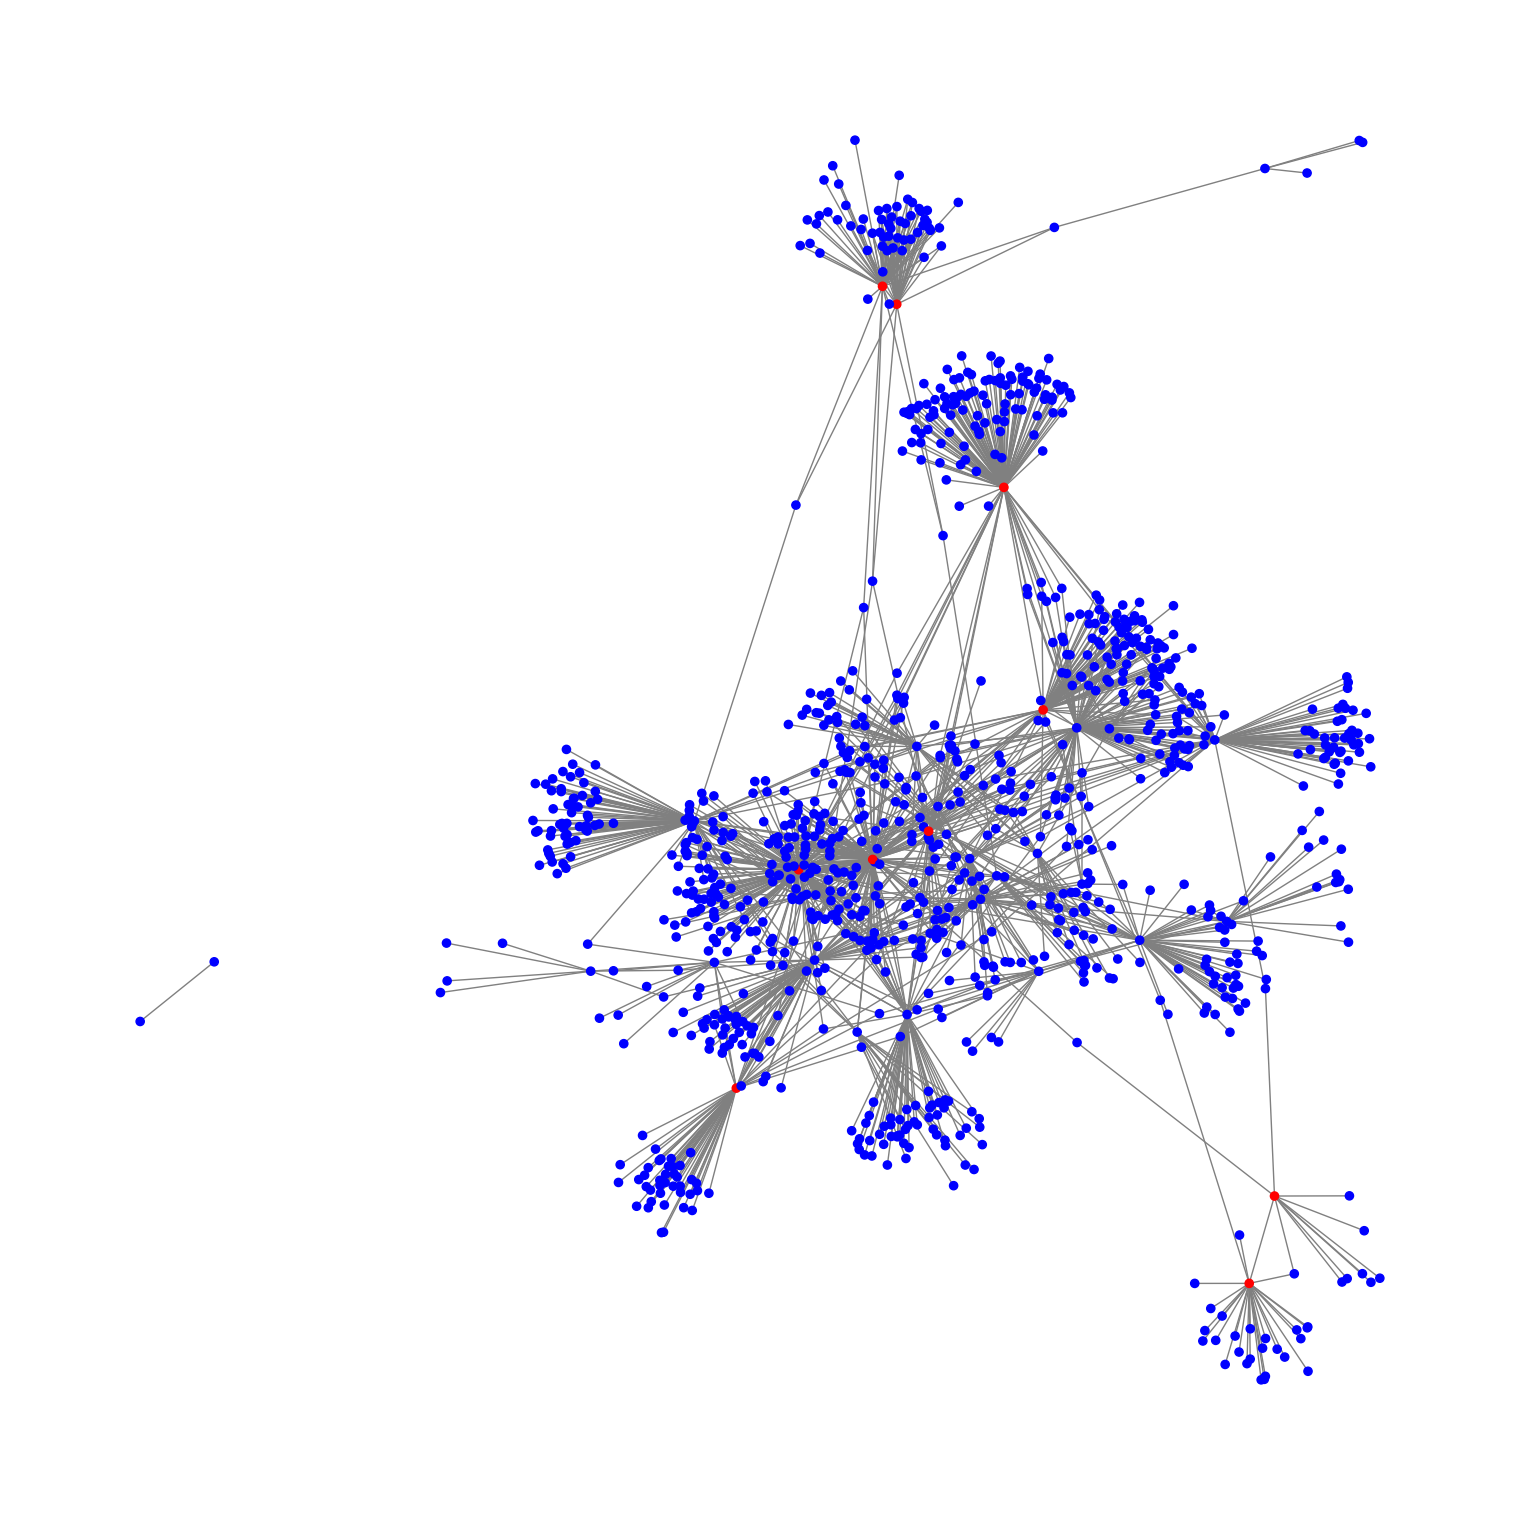

In [6]:
def ex1_4(graph=None):
    if graph is None:
        graph = ex1_1(num_maximum_edges=1500)
    graph = ex1_2(graph)
    graph = ex1_3(graph)

    anomaly_scores = [(node, graph.nodes[node]['anomaly_score']) for node in graph.nodes()]
    sorted_anomaly_scores = sorted(anomaly_scores, key=lambda x: x[1], reverse=True)

    TOP = 10
    print(f'Top {TOP} Anomaly Scores:')
    for node, anomaly_score in sorted_anomaly_scores[:TOP]:
        print(f'Node: {node} Anomaly Score: {anomaly_score}')

    anomaly_nodes = set(node for node, _ in sorted_anomaly_scores[:TOP])

    plt.figure(figsize=(15, 15))
    positions = nx.spring_layout(graph, seed=23)

    node_colors = ['blue' if node not in anomaly_nodes else 'red' for node in graph.nodes()]

    nx.draw(graph, pos=positions, node_color=node_colors, edge_color='gray', node_size=35)


ex1_4(graph=None)

Number of Nodes: 1103
Number of Edges: 1458
Linear Regression: C=0.5641203797554226 theta=0.8565427600164709
Top 10 Anomaly Scores:
Node: 101811 Anomaly Score: 1.0000000004051959
Node: 5412 Anomaly Score: 1.0
Node: 71583 Anomaly Score: 0.8725582110034451
Node: 92357 Anomaly Score: 0.8390885727573946
Node: 97966 Anomaly Score: 0.7447655049506007
Node: 83560 Anomaly Score: 0.6753768415173503
Node: 60471 Anomaly Score: 0.5419354509705124
Node: 47255 Anomaly Score: 0.5116249880531016
Node: 106274 Anomaly Score: 0.43256055692019874
Node: 76529 Anomaly Score: 0.42593442298456446


c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


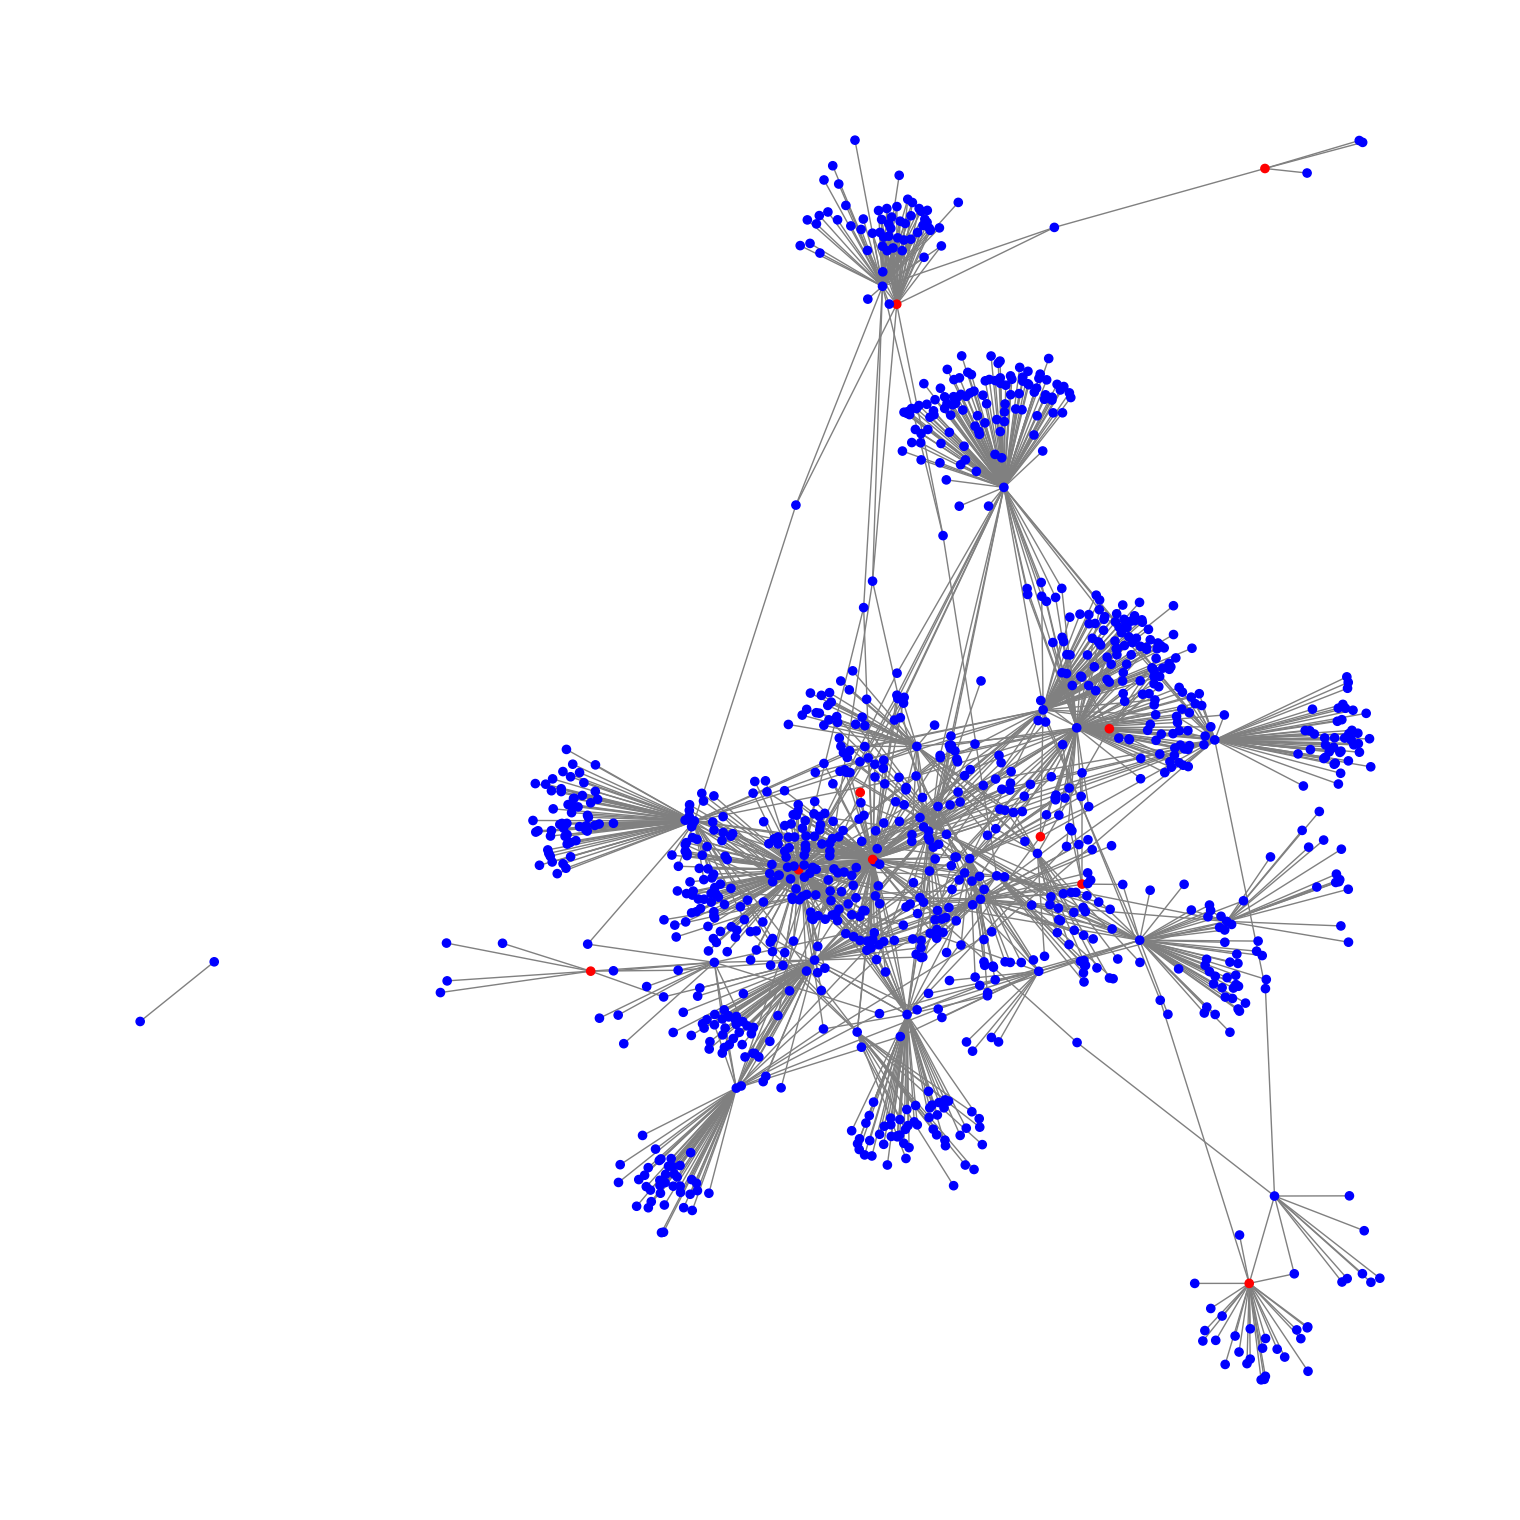

In [7]:
def ex1_5(graph=None):
    if graph is None:
        graph = ex1_1(num_maximum_edges=1500)
    graph = ex1_2(graph)
    graph = ex1_3(graph)

    old_anomaly_scores = np.array([graph.nodes[node]['anomaly_score'] for node in graph.nodes()])
    min_max_scaler = MinMaxScaler()
    min_max_scaler.fit(old_anomaly_scores.reshape(-1, 1))

    for node in graph.nodes():
        old_anomaly_score = graph.nodes[node]['anomaly_score']
        normalized_anomaly_score = min_max_scaler.transform(np.array(old_anomaly_score).reshape(1, 1))[0][0]
        graph.nodes[node]['anomaly_score'] = normalized_anomaly_score

    egonet_num_edges = np.array([graph.nodes[node]['egonet_num_edges'] for node in graph.nodes()])
    egonet_num_neighbors = np.array([graph.nodes[node]['egonet_num_neighbors'] for node in graph.nodes()])
    lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
    lof.fit(np.column_stack((egonet_num_edges, egonet_num_neighbors)))
    min_max_scaler = MinMaxScaler()
    min_max_scaler.fit(-lof.negative_outlier_factor_.reshape(-1, 1))
    normalized_negative_outlier_factors = min_max_scaler.transform(-lof.negative_outlier_factor_.reshape(-1, 1)).flatten()
    for idx, node in enumerate(graph.nodes()):
        graph.nodes[node]['anomaly_score'] += normalized_negative_outlier_factors[idx]

    anomaly_scores = [(node, graph.nodes[node]['anomaly_score']) for node in graph.nodes()]
    sorted_anomaly_scores = sorted(anomaly_scores, key=lambda x: x[1], reverse=True)

    TOP = 10
    print(f'Top {TOP} Anomaly Scores:')
    for node, anomaly_score in sorted_anomaly_scores[:TOP]:
        print(f'Node: {node} Anomaly Score: {anomaly_score}')

    anomaly_nodes = set(node for node, _ in sorted_anomaly_scores[:TOP])

    plt.figure(figsize=(15, 15))
    positions = nx.spring_layout(graph, seed=23)

    node_colors = ['blue' if node not in anomaly_nodes else 'red' for node in graph.nodes()]

    nx.draw(graph, pos=positions, node_color=node_colors, edge_color='gray', node_size=35)


ex1_5(graph=None)

### Exercise 2

Linear Regression: C=0.03379763568566592 theta=2.88838630118753
Top 10 Anomaly Scores:
Node: clique-19 Anomaly Score: 3.6432432259234324
Node: clique-39 Anomaly Score: 3.6432432259234324
Node: clique-51 Anomaly Score: 3.6432432259234324
Node: clique-57 Anomaly Score: 3.6432432259234324
Node: clique-59 Anomaly Score: 3.6432432259234324
Node: clique-73 Anomaly Score: 3.6432432259234324
Node: clique-77 Anomaly Score: 3.6432432259234324
Node: clique-79 Anomaly Score: 3.6432432259234324
Node: clique-94 Anomaly Score: 3.6432432259234324
Node: clique-99 Anomaly Score: 3.6432432259234324
Linear Regression: C=0.03379763568566592 theta=2.88838630118753
Top 10 Anomaly Scores:
Node: clique-0 Anomaly Score: 1.683349998468299
Node: clique-20 Anomaly Score: 1.683349998468299
Node: clique-40 Anomaly Score: 1.683349998468299
Node: clique-60 Anomaly Score: 1.683349998468299
Node: clique-80 Anomaly Score: 1.683349998468299
Node: clique-100 Anomaly Score: 1.683349998468299
Node: clique-120 Anomaly Score: 

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


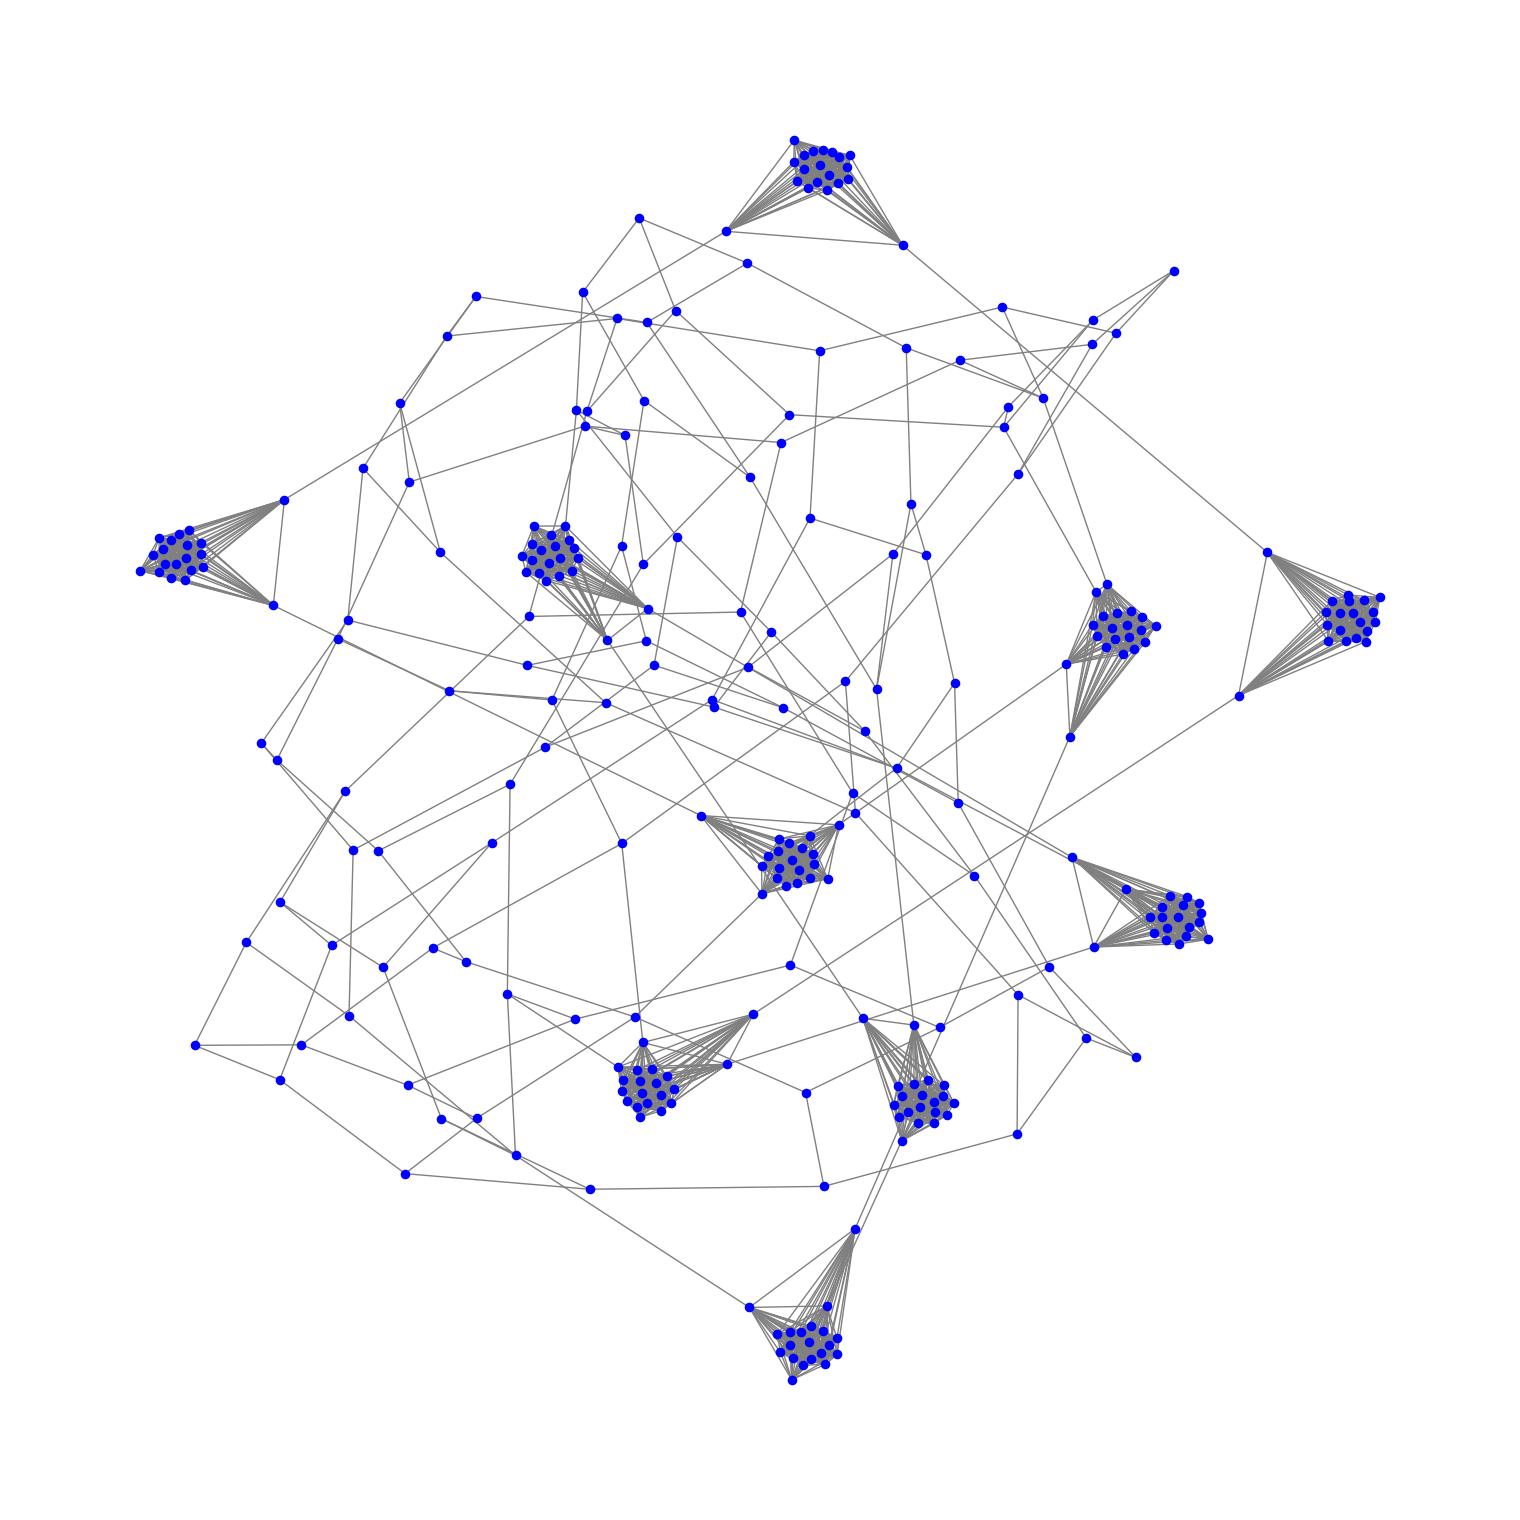

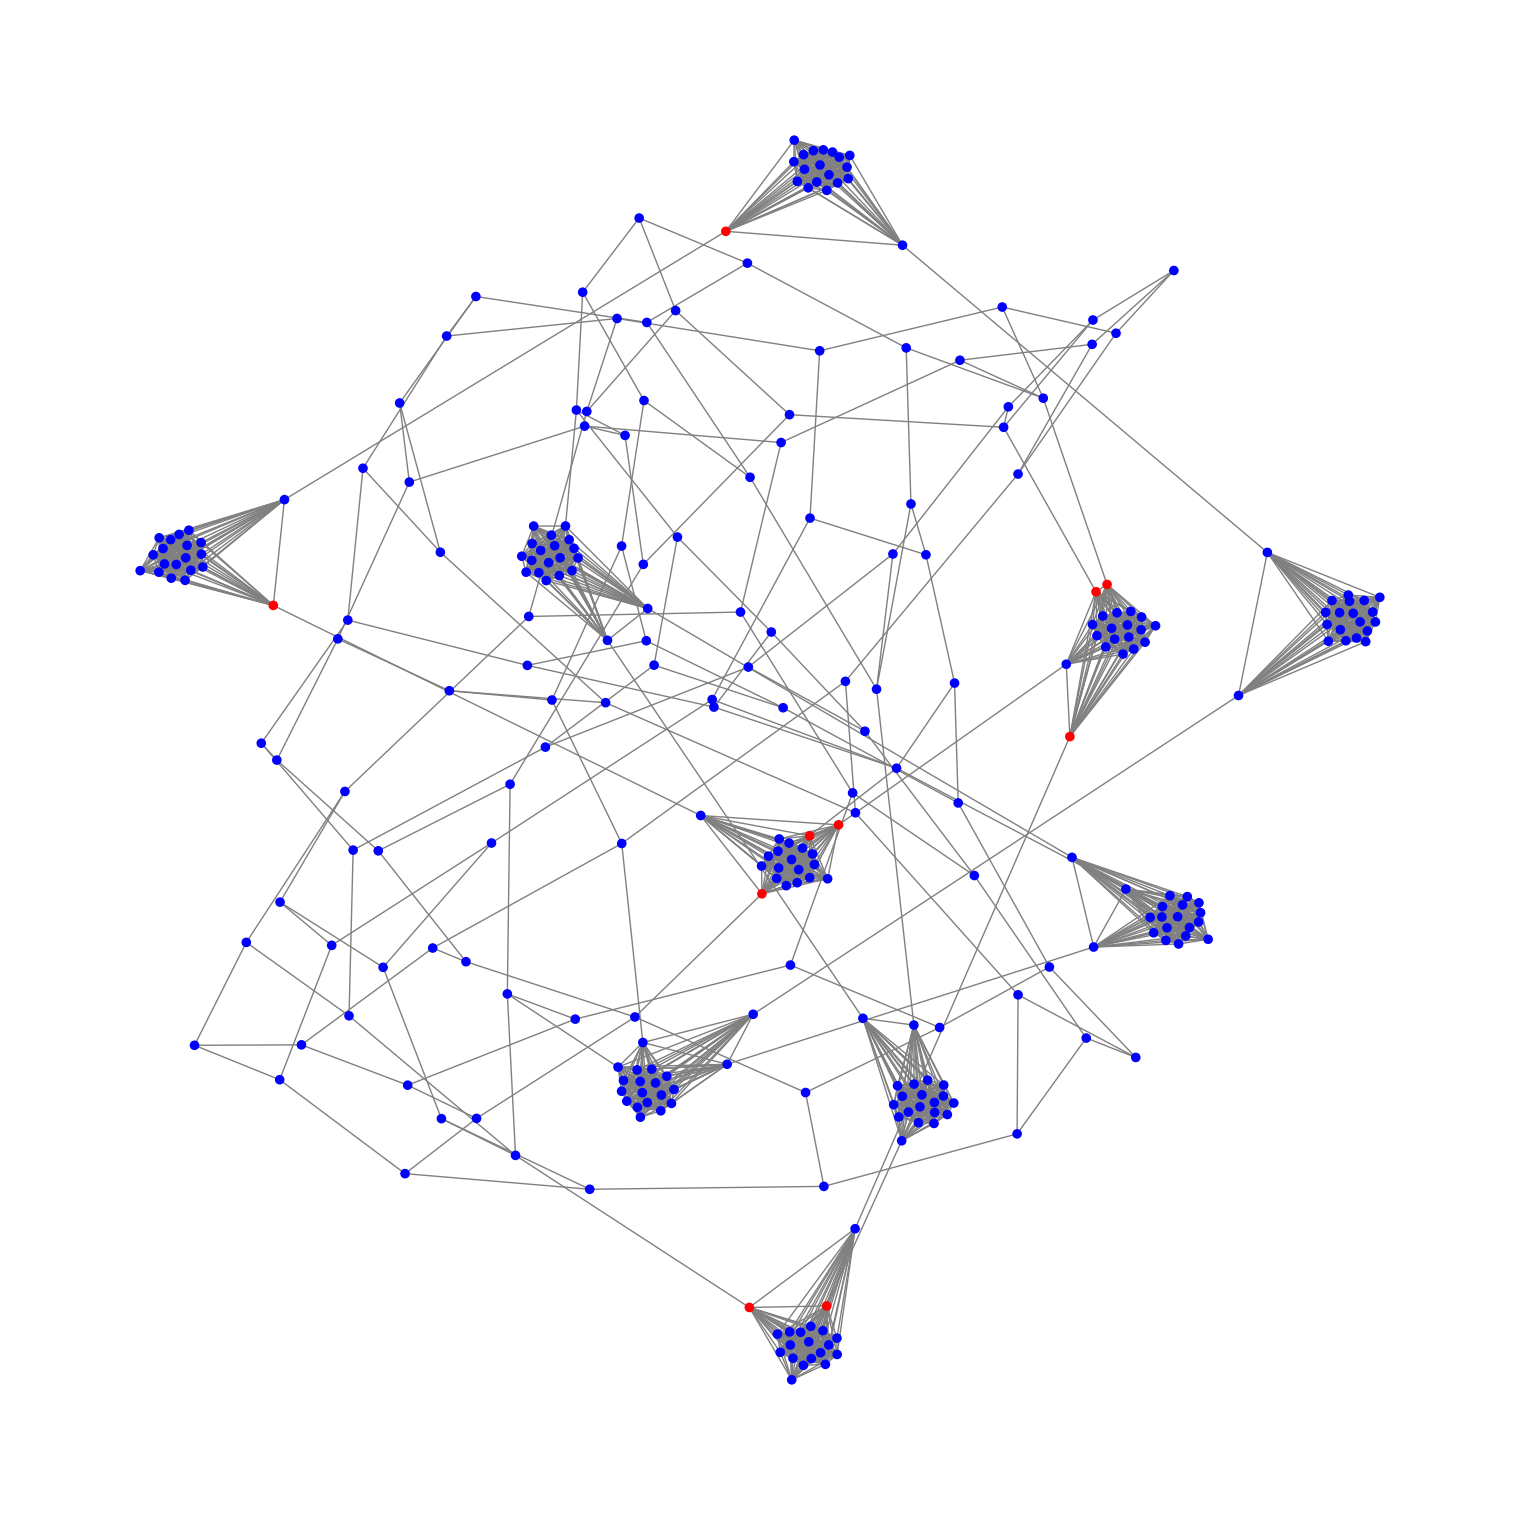

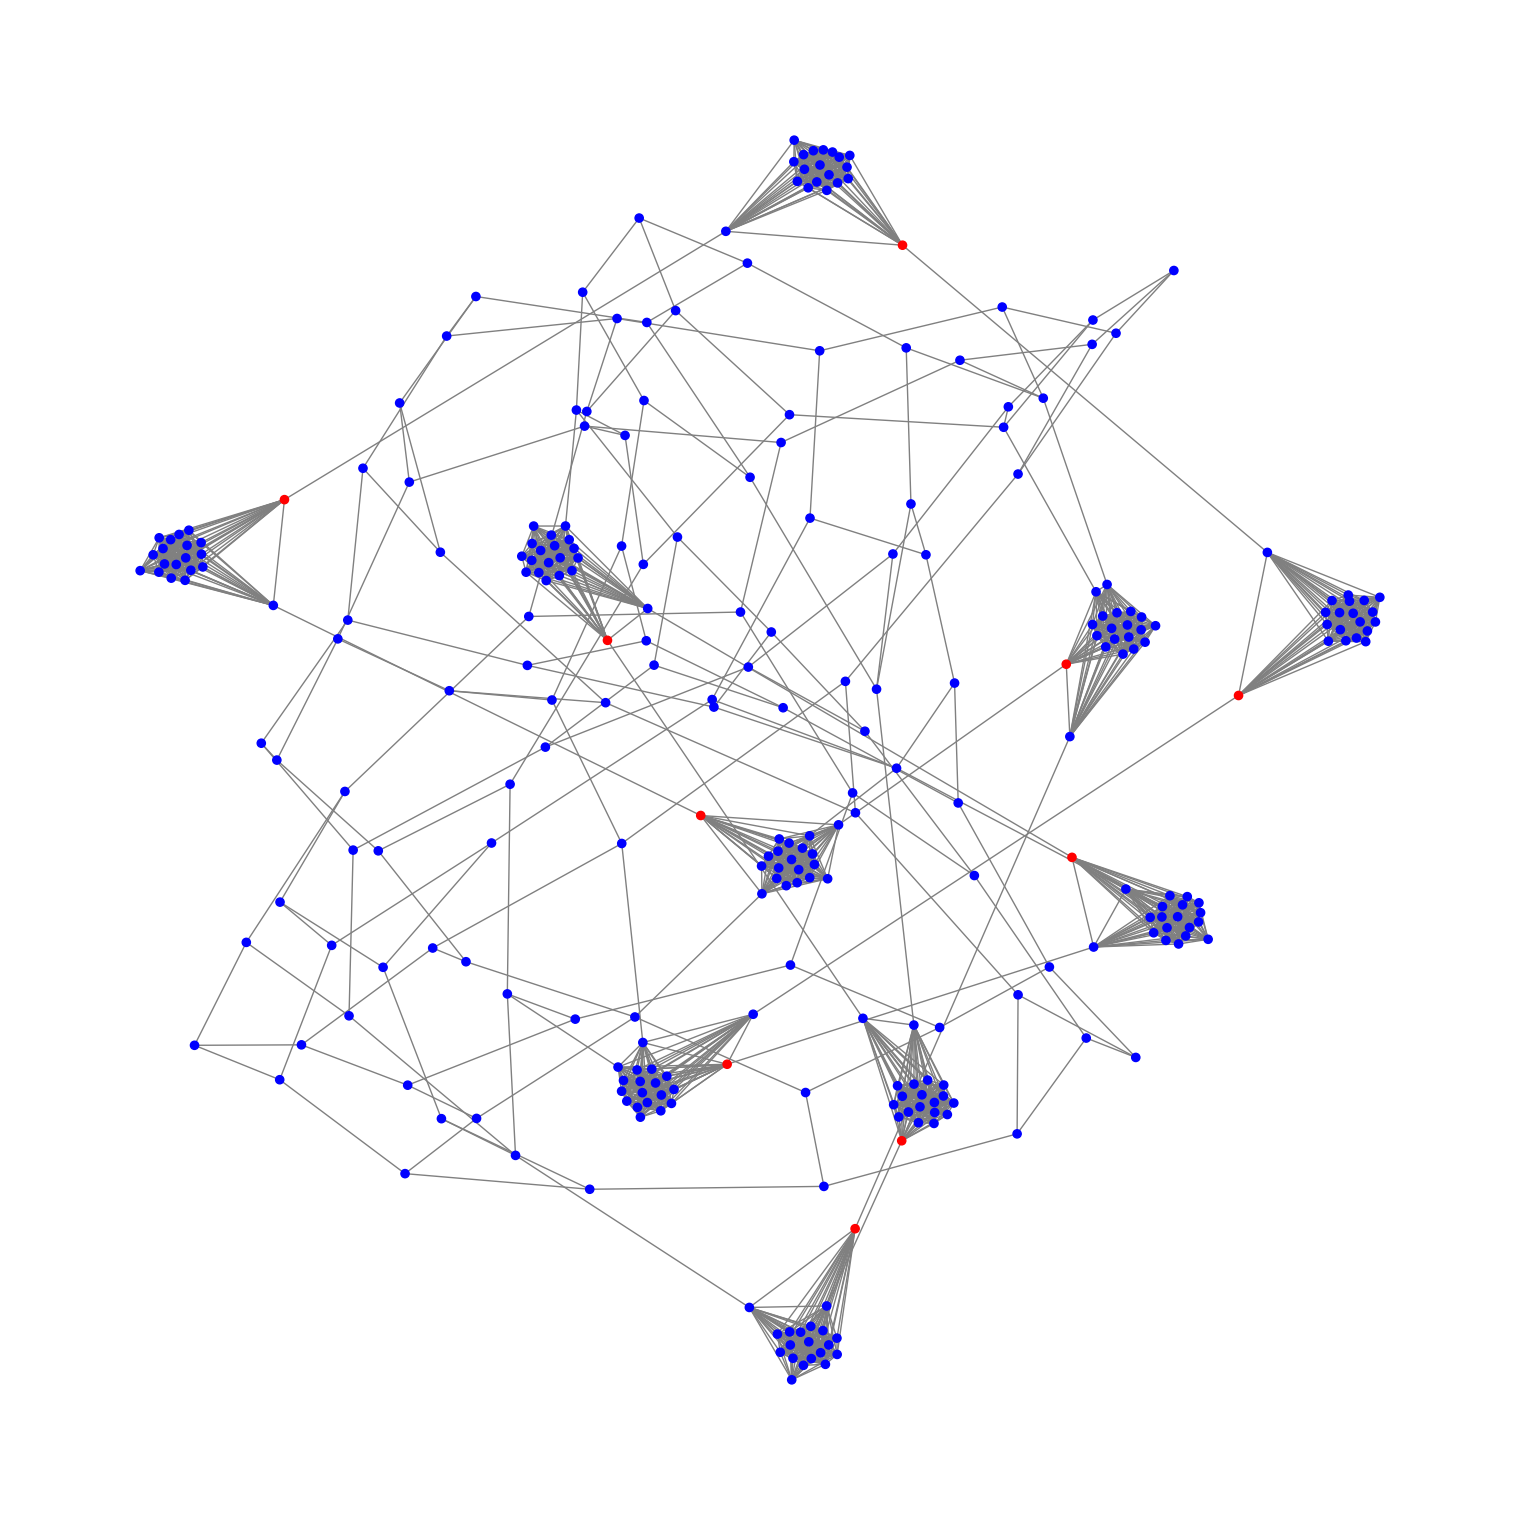

In [8]:
def ex2_1():
    graph_0 = nx.random_regular_graph(d=3, n=100)
    graph_1 = nx.connected_caveman_graph(l=10, k=20)

    graph_union = nx.union(graph_0, graph_1, rename=('regular-', 'clique-'))

    NUM_RANDOM_EDGES = 10
    nodes_graph_0 = list(graph_0.nodes())
    nodes_graph_1 = list(graph_1.nodes())
    for _ in range(NUM_RANDOM_EDGES):
        node_0 = np.random.choice(nodes_graph_0)
        node_1 = np.random.choice(nodes_graph_1)
        if not graph_union.has_edge(f'regular-{node_0}', f'clique-{node_1}'):
            graph_union.add_edge(f'regular-{node_0}', f'clique-{node_1}')

    nx.set_edge_attributes(graph_union, 1, 'weight')

    plt.figure(figsize=(15, 15))
    positions = nx.spring_layout(graph_union, seed=23)

    nx.draw(graph_union, pos=positions, node_color='blue', edge_color='gray', node_size=35)

    ex1_4(graph=copy.deepcopy(graph_union))
    ex1_5(graph=copy.deepcopy(graph_union))


ex2_1()

In [10]:
def ex2_anomaly_scores(graph):

    nodes = np.array(list(graph.nodes()))
    egonet_num_edges = np.array([graph.nodes[node]['egonet_num_edges'] for node in graph.nodes()])
    egonet_total_weights = np.array([graph.nodes[node]['egonet_total_weight'] for node in graph.nodes()])

    filter_mask = ((0 < egonet_num_edges) & (0 < egonet_total_weights))
    nodes = nodes[filter_mask]
    egonet_num_edges = egonet_num_edges[filter_mask]
    egonet_total_weights = egonet_total_weights[filter_mask]

    X = np.log(egonet_num_edges).reshape(-1, 1)
    Y = np.log(egonet_total_weights).reshape(-1, 1)

    linear_regression = LinearRegression()
    linear_regression.fit(X, Y)

    C = np.exp(linear_regression.intercept_[0])
    theta = linear_regression.coef_[0][0]

    print(f'Linear Regression: C={C} theta={theta}')

    egonet_total_weights_pred = C * (egonet_num_edges ** theta)

    for idx, node in enumerate(nodes):
        numerator = max(egonet_total_weights[idx], egonet_total_weights_pred[idx])
        denominator = min(egonet_total_weights[idx], egonet_total_weights_pred[idx])
        logarithm = np.log(np.abs(egonet_total_weights[idx] - egonet_total_weights_pred[idx]) + 1.0)

        anomaly_score = (numerator / denominator) * logarithm
        graph.nodes[node]['anomaly_score'] = anomaly_score

    for node in graph.nodes():
        if node not in nodes:
            graph.nodes[node]['anomaly_score'] = 0.0

    # Local Outlier Factor

    old_anomaly_scores = np.array([graph.nodes[node]['anomaly_score'] for node in graph.nodes()])
    min_max_scaler = MinMaxScaler()
    min_max_scaler.fit(old_anomaly_scores.reshape(-1, 1))

    for node in graph.nodes():
        old_anomaly_score = graph.nodes[node]['anomaly_score']
        normalized_anomaly_score = min_max_scaler.transform(np.array(old_anomaly_score).reshape(1, 1))[0][0]
        graph.nodes[node]['anomaly_score'] = normalized_anomaly_score

    egonet_total_weights = np.array([graph.nodes[node]['egonet_total_weight'] for node in graph.nodes()])
    egonet_num_edges = np.array([graph.nodes[node]['egonet_num_edges'] for node in graph.nodes()])
    lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
    lof.fit(np.column_stack((egonet_total_weights, egonet_num_edges)))
    min_max_scaler = MinMaxScaler()
    min_max_scaler.fit(-lof.negative_outlier_factor_.reshape(-1, 1))
    normalized_negative_outlier_factors = min_max_scaler.transform(-lof.negative_outlier_factor_.reshape(-1, 1)).flatten()
    for idx, node in enumerate(graph.nodes()):
        graph.nodes[node]['anomaly_score'] += normalized_negative_outlier_factors[idx]

    return graph

Selected Nodes for Heavy Vicinity: regular_0-20 regular_1-55
Linear Regression: C=1.0 theta=0.9999999999999999
Top 4 Anomaly Scores:
Node: regular_1-24 Anomaly Score: 1.0000000000000002
Node: regular_1-32 Anomaly Score: 1.0000000000000002
Node: regular_1-42 Anomaly Score: 1.0000000000000002
Node: regular_1-75 Anomaly Score: 1.0000000000000002


c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


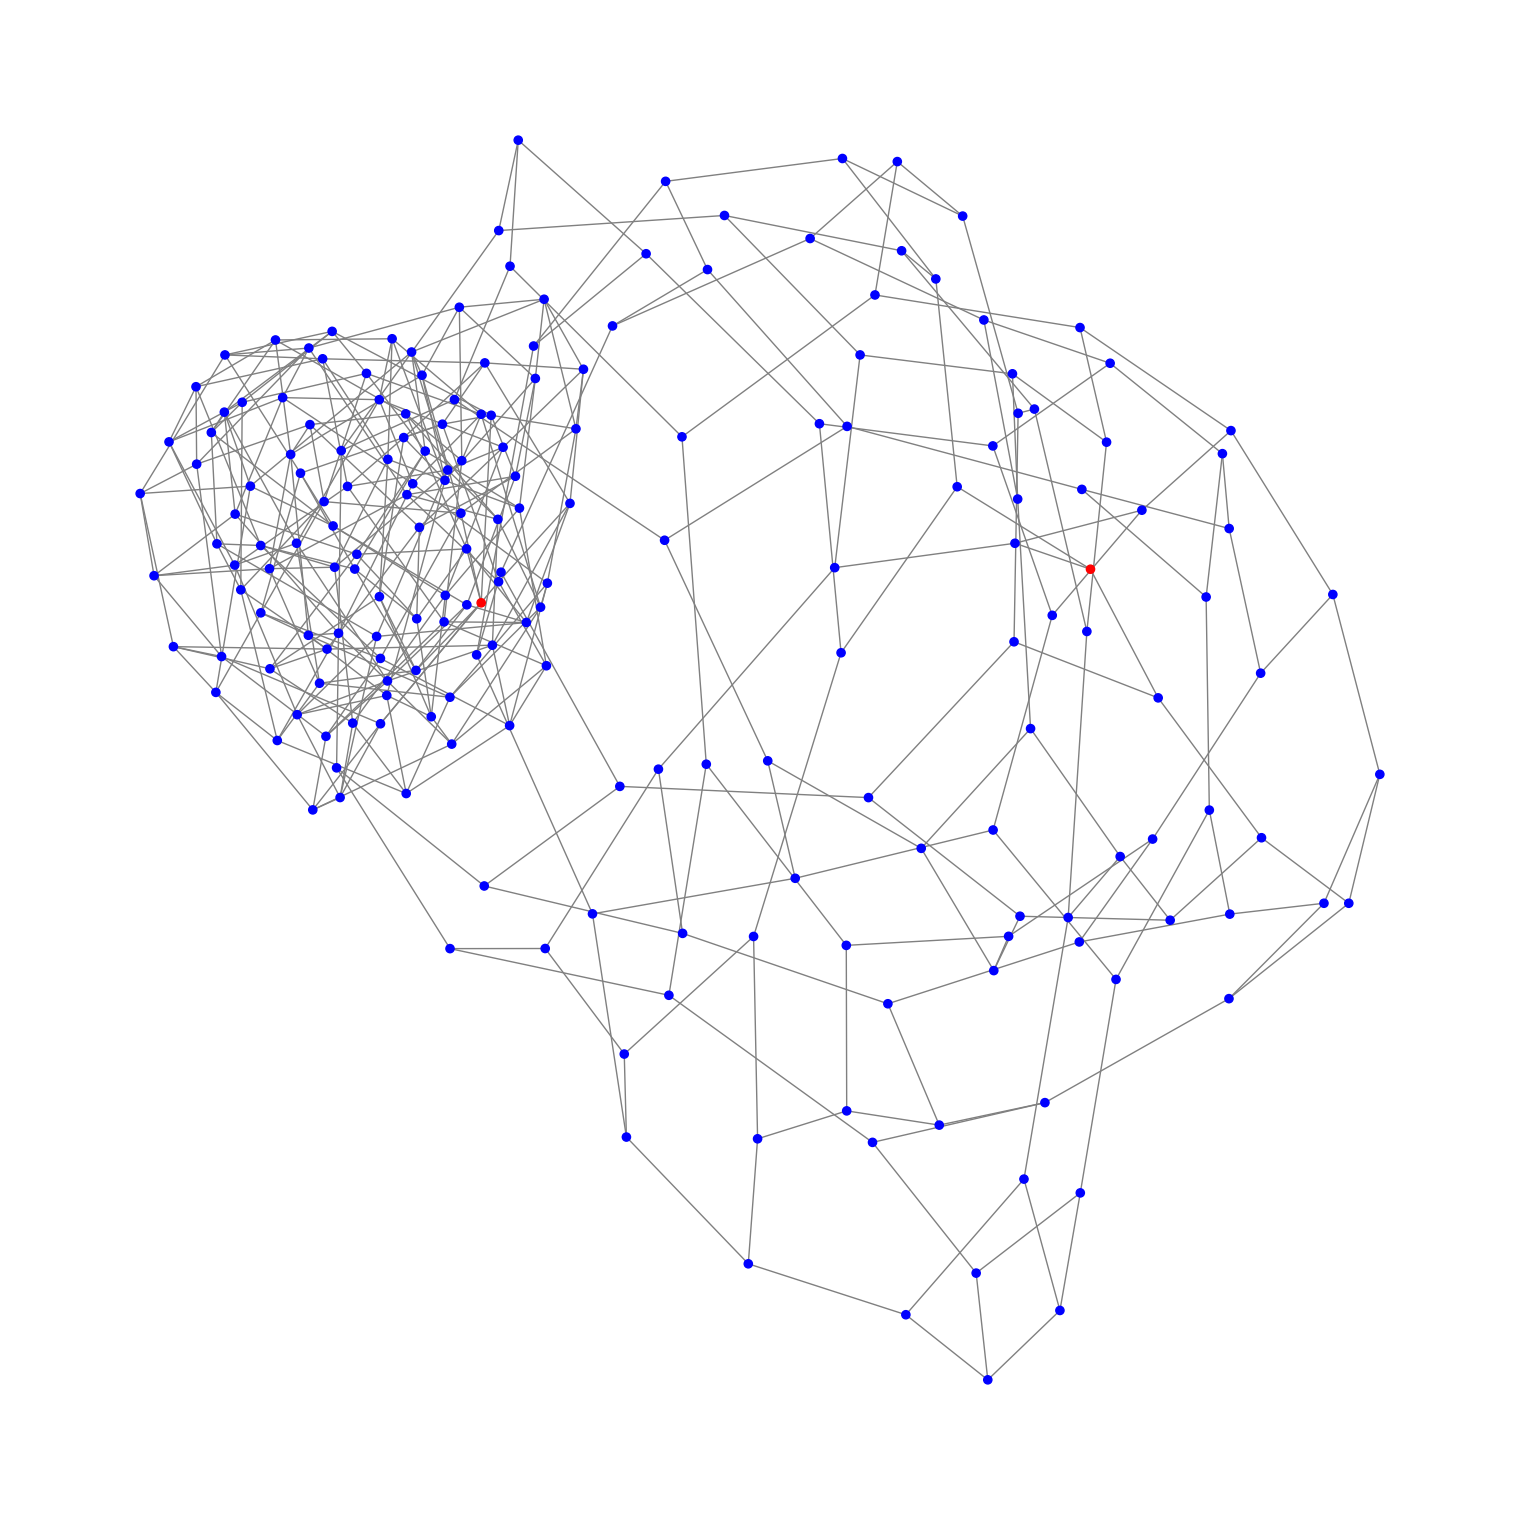

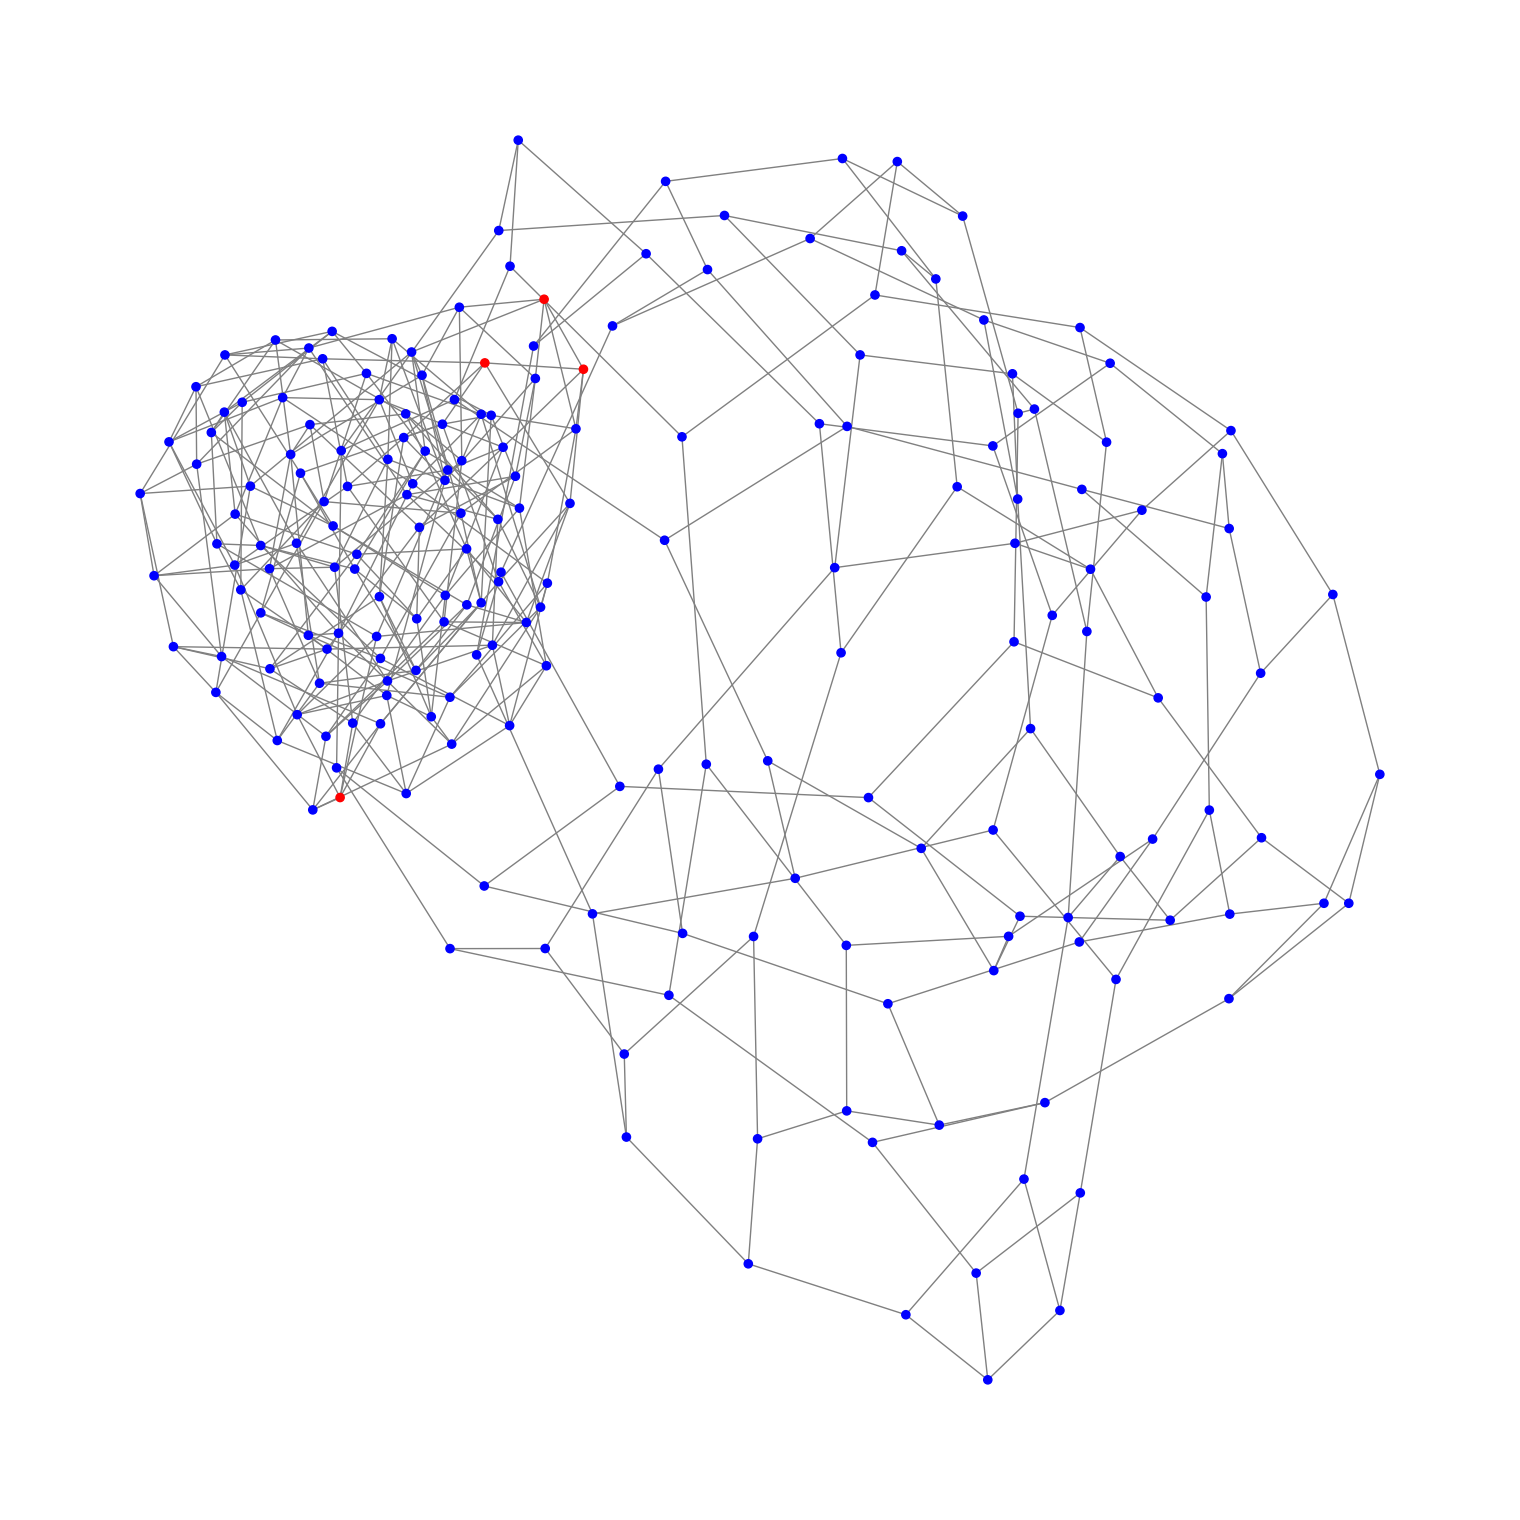

In [12]:
def ex2_2():
    graph_0 = nx.random_regular_graph(d=3, n=100)
    graph_1 = nx.random_regular_graph(d=5, n=100)

    graph_union = nx.union(graph_0, graph_1, rename=('regular_0-', 'regular_1-'))

    for edge in graph_union.edges():
        graph_union.add_edge(edge[0], edge[1], weight=1)

    random_node_0, random_node_1 = np.random.choice(list(graph_union.nodes()), size=2, replace=False)
    neighbors_node_0 = list(graph_union.neighbors(random_node_0))
    egonet_node_0 = graph_union.subgraph(neighbors_node_0)
    for egonet_edge in egonet_node_0.edges():
        graph_union[egonet_edge[0]][egonet_edge[1]]['weight'] += 10

    neighbors_node_1 = list(graph_union.neighbors(random_node_1))
    egonet_node_1 = graph_union.subgraph(neighbors_node_1)
    for egonet_edge in egonet_node_1.edges():
        graph_union[egonet_edge[0]][egonet_edge[1]]['weight'] += 10

    print(f'Selected Nodes for Heavy Vicinity: {random_node_0} {random_node_1}')

    node_colors = ['red' if (node == random_node_0 or node == random_node_1)
                   else 'blue' for node in graph_union.nodes()]

    plt.figure(figsize=(15, 15))
    positions = nx.spring_layout(graph_union, seed=23)

    nx.draw(graph_union, pos=positions, node_color=node_colors, edge_color='gray', node_size=35)

    graph_union = ex1_2(graph_union)
    graph_union = ex2_anomaly_scores(graph_union)

    anomaly_scores = [(node, graph_union.nodes[node]['anomaly_score']) for node in graph_union.nodes()]
    sorted_anomaly_scores = sorted(anomaly_scores, key=lambda x: x[1], reverse=True)

    TOP = 4
    print(f'Top {TOP} Anomaly Scores:')
    for node, anomaly_score in sorted_anomaly_scores[:TOP]:
        print(f'Node: {node} Anomaly Score: {anomaly_score}')

    anomaly_nodes = set(node for node, _ in sorted_anomaly_scores[:TOP])

    plt.figure(figsize=(15, 15))
    positions = nx.spring_layout(graph_union, seed=23)

    node_colors = ['blue' if node not in anomaly_nodes else 'red' for node in graph_union.nodes()]

    nx.draw(graph_union, pos=positions, node_color=node_colors, edge_color='gray', node_size=35)


ex2_2()

### Exercise 3